# [LAB 07] 6. 일원분산분석
## #연습문제 -(2)

In [1]:
from hossam import load_data
from helpers import *
from pandas import pivot_table

📦 아이티윌 이광호 강사가 제작한 라이브러리를 사용중입니다.
📚 자세한 사용 방법은 https://py.hossam.kr 을 참고하세요.
📧 Email: leekh4232@gmail.com
🎬 Youtube: https://www.youtube.com/@hossam-codingclub
📝 Blog: https://blog.hossam.kr/
🔖 Version: 0.5.19


#### 문제 1 - 독서 점수의 평균에 차이가 있다면 구체적으로 어떤 차이가 있는지 검정하라

In [2]:
df1 = load_data('reading')
df1.head()

📚 유아들을 대상으로 세 가지 읽는 방법을 비교,실험하여 얻은 독서평가 점수 데이터 (출처: 방송통신대학교 통계학개론)


,독서방법,점수
0,B,7.700
1,B,1.500
2,B,4.300
3,B,5.400
4,B,4.300


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

B vs. D: Custom statistical test, P_val:3.400e-01
D vs. G: Custom statistical test, P_val:4.031e-04
B vs. G: Custom statistical test, P_val:8.764e-05


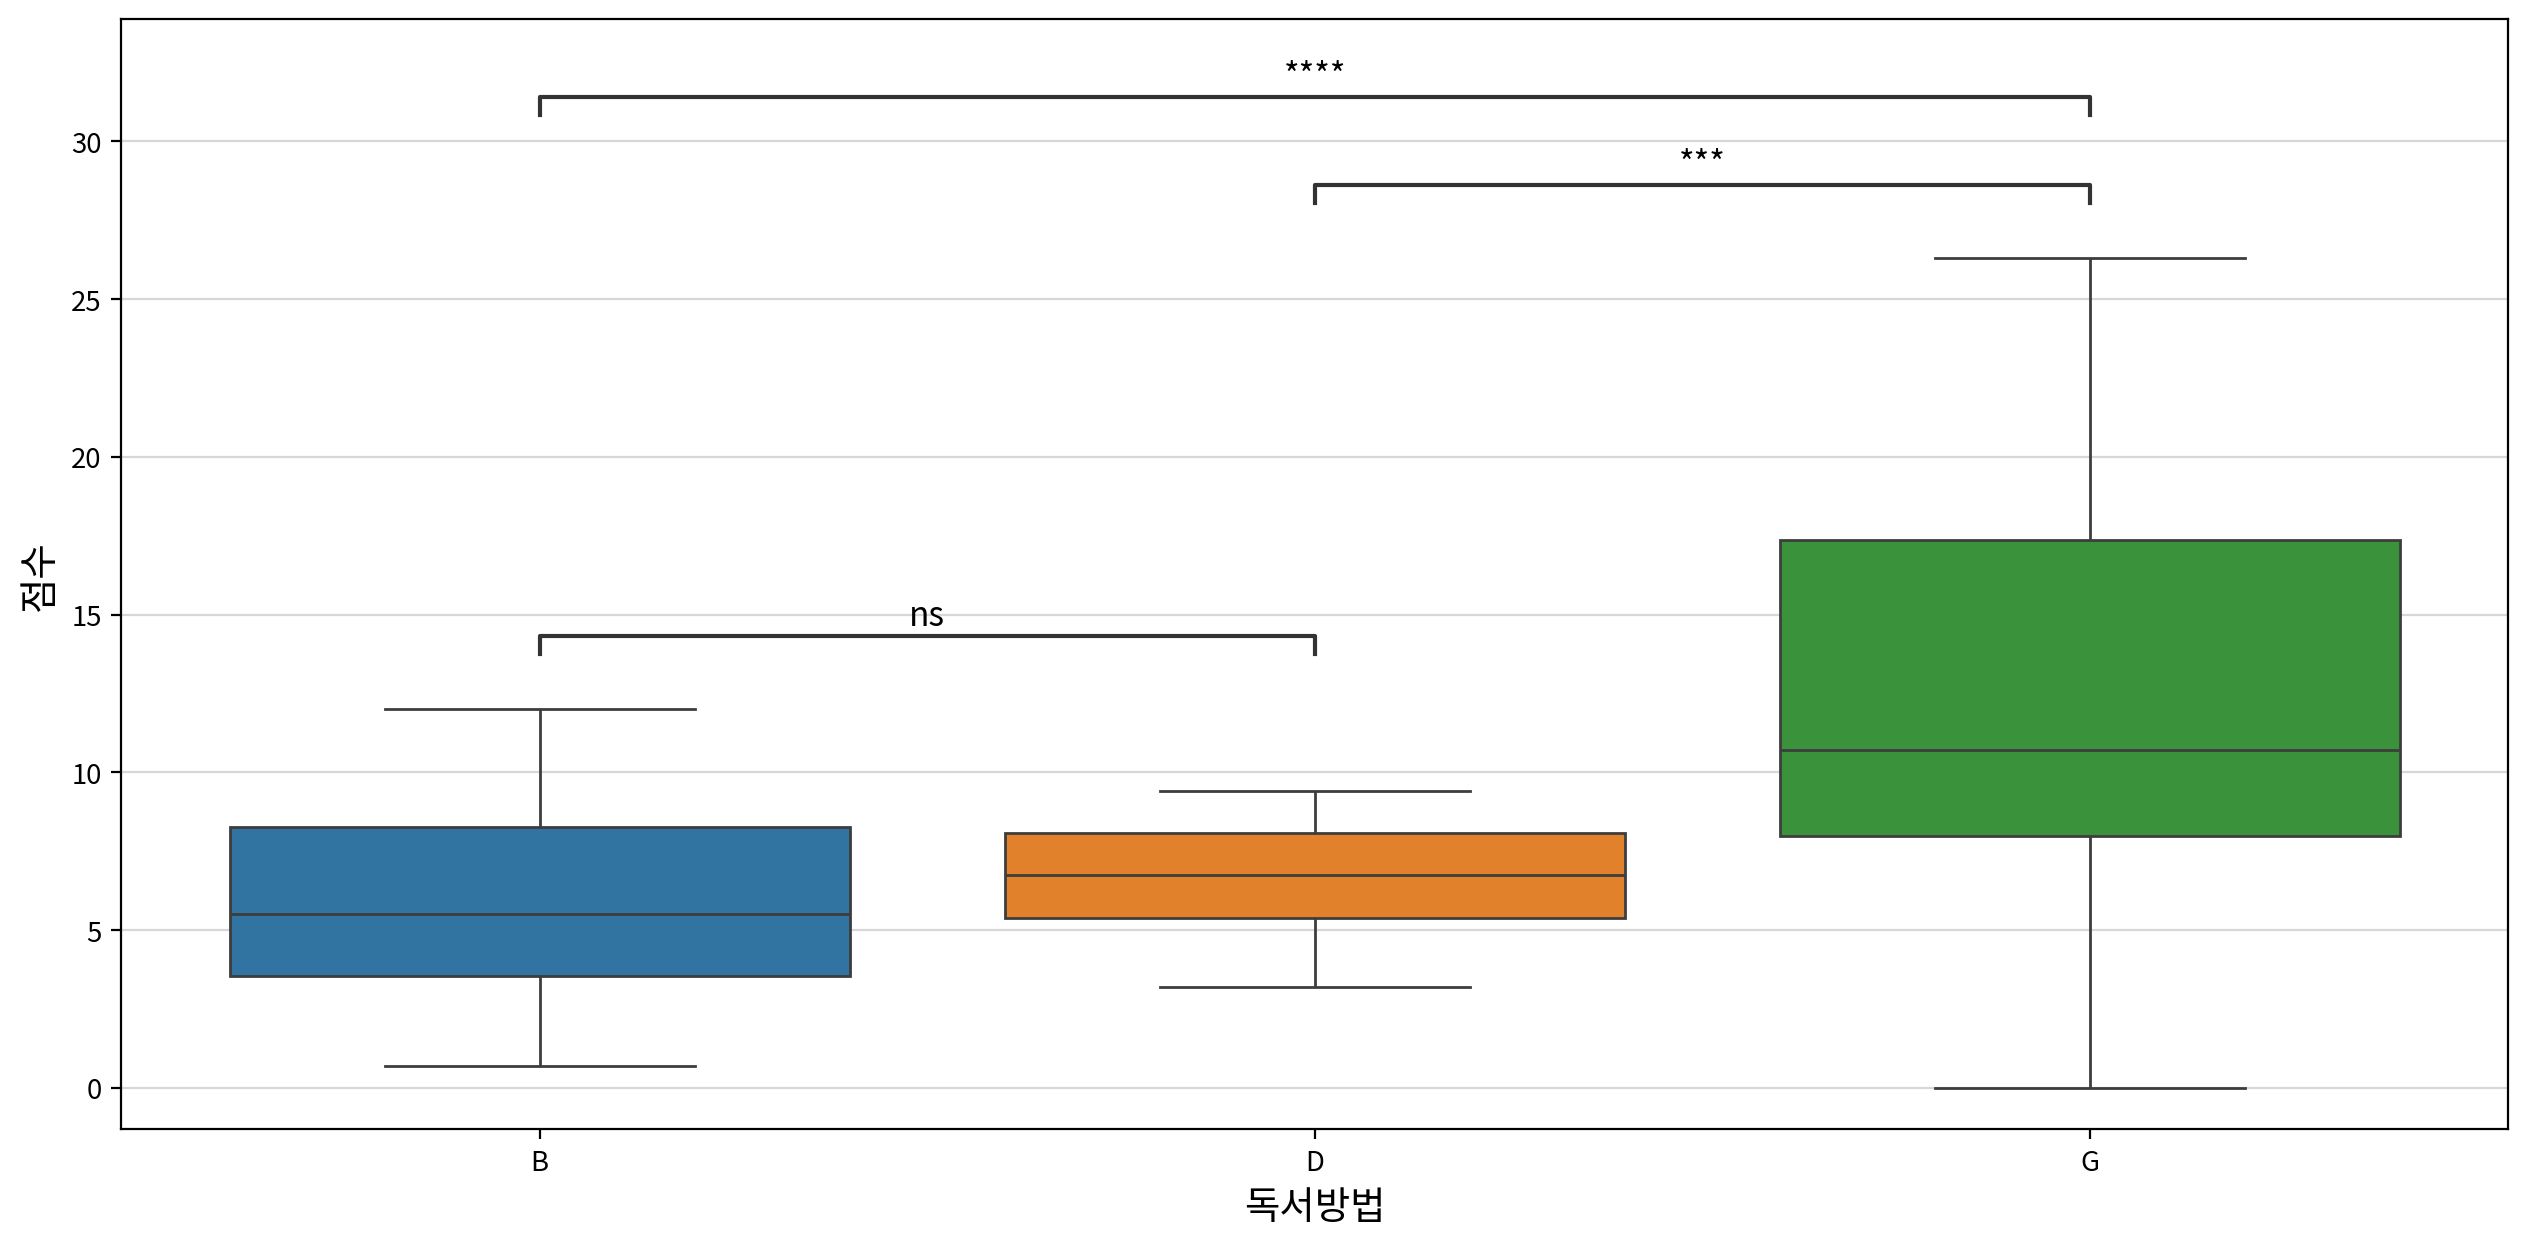

,test,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges,significant,effect_size
0,Games-Howell,B,D,5.732,6.693,-0.961,0.677,-1.421,40.563,0.340,-0.376,False,Small
1,Games-Howell,B,G,5.732,12.531,-6.799,1.457,-4.666,42.964,0.000,-1.137,True,Large
2,Games-Howell,D,G,6.693,12.531,-5.838,1.363,-4.284,34.361,0.000,-1.044,True,Large


In [3]:
my_stats.posthoc_oneway(df1, y='점수', between='독서방법')

- 데이터가 등분산성을 만족하지 않아 Games-Howell을 수행하였다.
- 사후 분석 결과, B와 G 집단, D와 G집단의 평균 차이가 통계적으로 유의하였다(p <0.05)
- B와 G 집단의 평균은 각각 5.732, 12.531로 평균 차이는 -6.799였으며 효과크기는 -1.137로 큰 수준이었다. 즉 G집단의 평균이 B집단보다 유의하게 높았다.
- D와 G 집단의 평균은 각각 6.693, 12.531로 평균 차이는 -5.838이었으며, 효과 크기는 -1.044로 큰 수준이었다. 즉 G집단의 평균이 D집단보다 유의하게 높았다.
- 반면 B와 D(p>=0.05)의 평균차이는 통계적으로 유의하지 않았다.

#### 문제 2- 서울시 상권 종류에 따라 평균 매출액에 차이가 있다면 구체적으로 어떤 차이가 있는지 검정하라

In [4]:
df2 = load_data('commercial')
df2.head()

📚 서울시의 2023년 상권에 따른 분기별 매출액과 매출건수에 대한 자료 (출처: 서울 열린데이터 광장)


,quarter,code,type,name,sales_amount,number_of_sales
0,1,3001491,관광특구,이태원 관광특구,72523644100,2496865
1,1,3001492,관광특구,명동 남대문 북창동 다동 무교동 관광특구,283332346393,10246122
2,1,3001493,관광특구,동대문패션타운 관광특구,81696730221,2880324
3,1,3001494,관광특구,종로·청계 관광특구,212062656625,4960006
4,1,3001495,관광특구,잠실 관광특구,231338386876,5995166


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

골목상권 vs. 관광특구: Custom statistical test, P_val:6.410e-09
관광특구 vs. 발달상권: Custom statistical test, P_val:7.128e-07
발달상권 vs. 전통시장: Custom statistical test, P_val:3.927e-13
골목상권 vs. 발달상권: Custom statistical test, P_val:7.272e-14
관광특구 vs. 전통시장: Custom statistical test, P_val:1.140e-08
골목상권 vs. 전통시장: Custom statistical test, P_val:0.000e+00


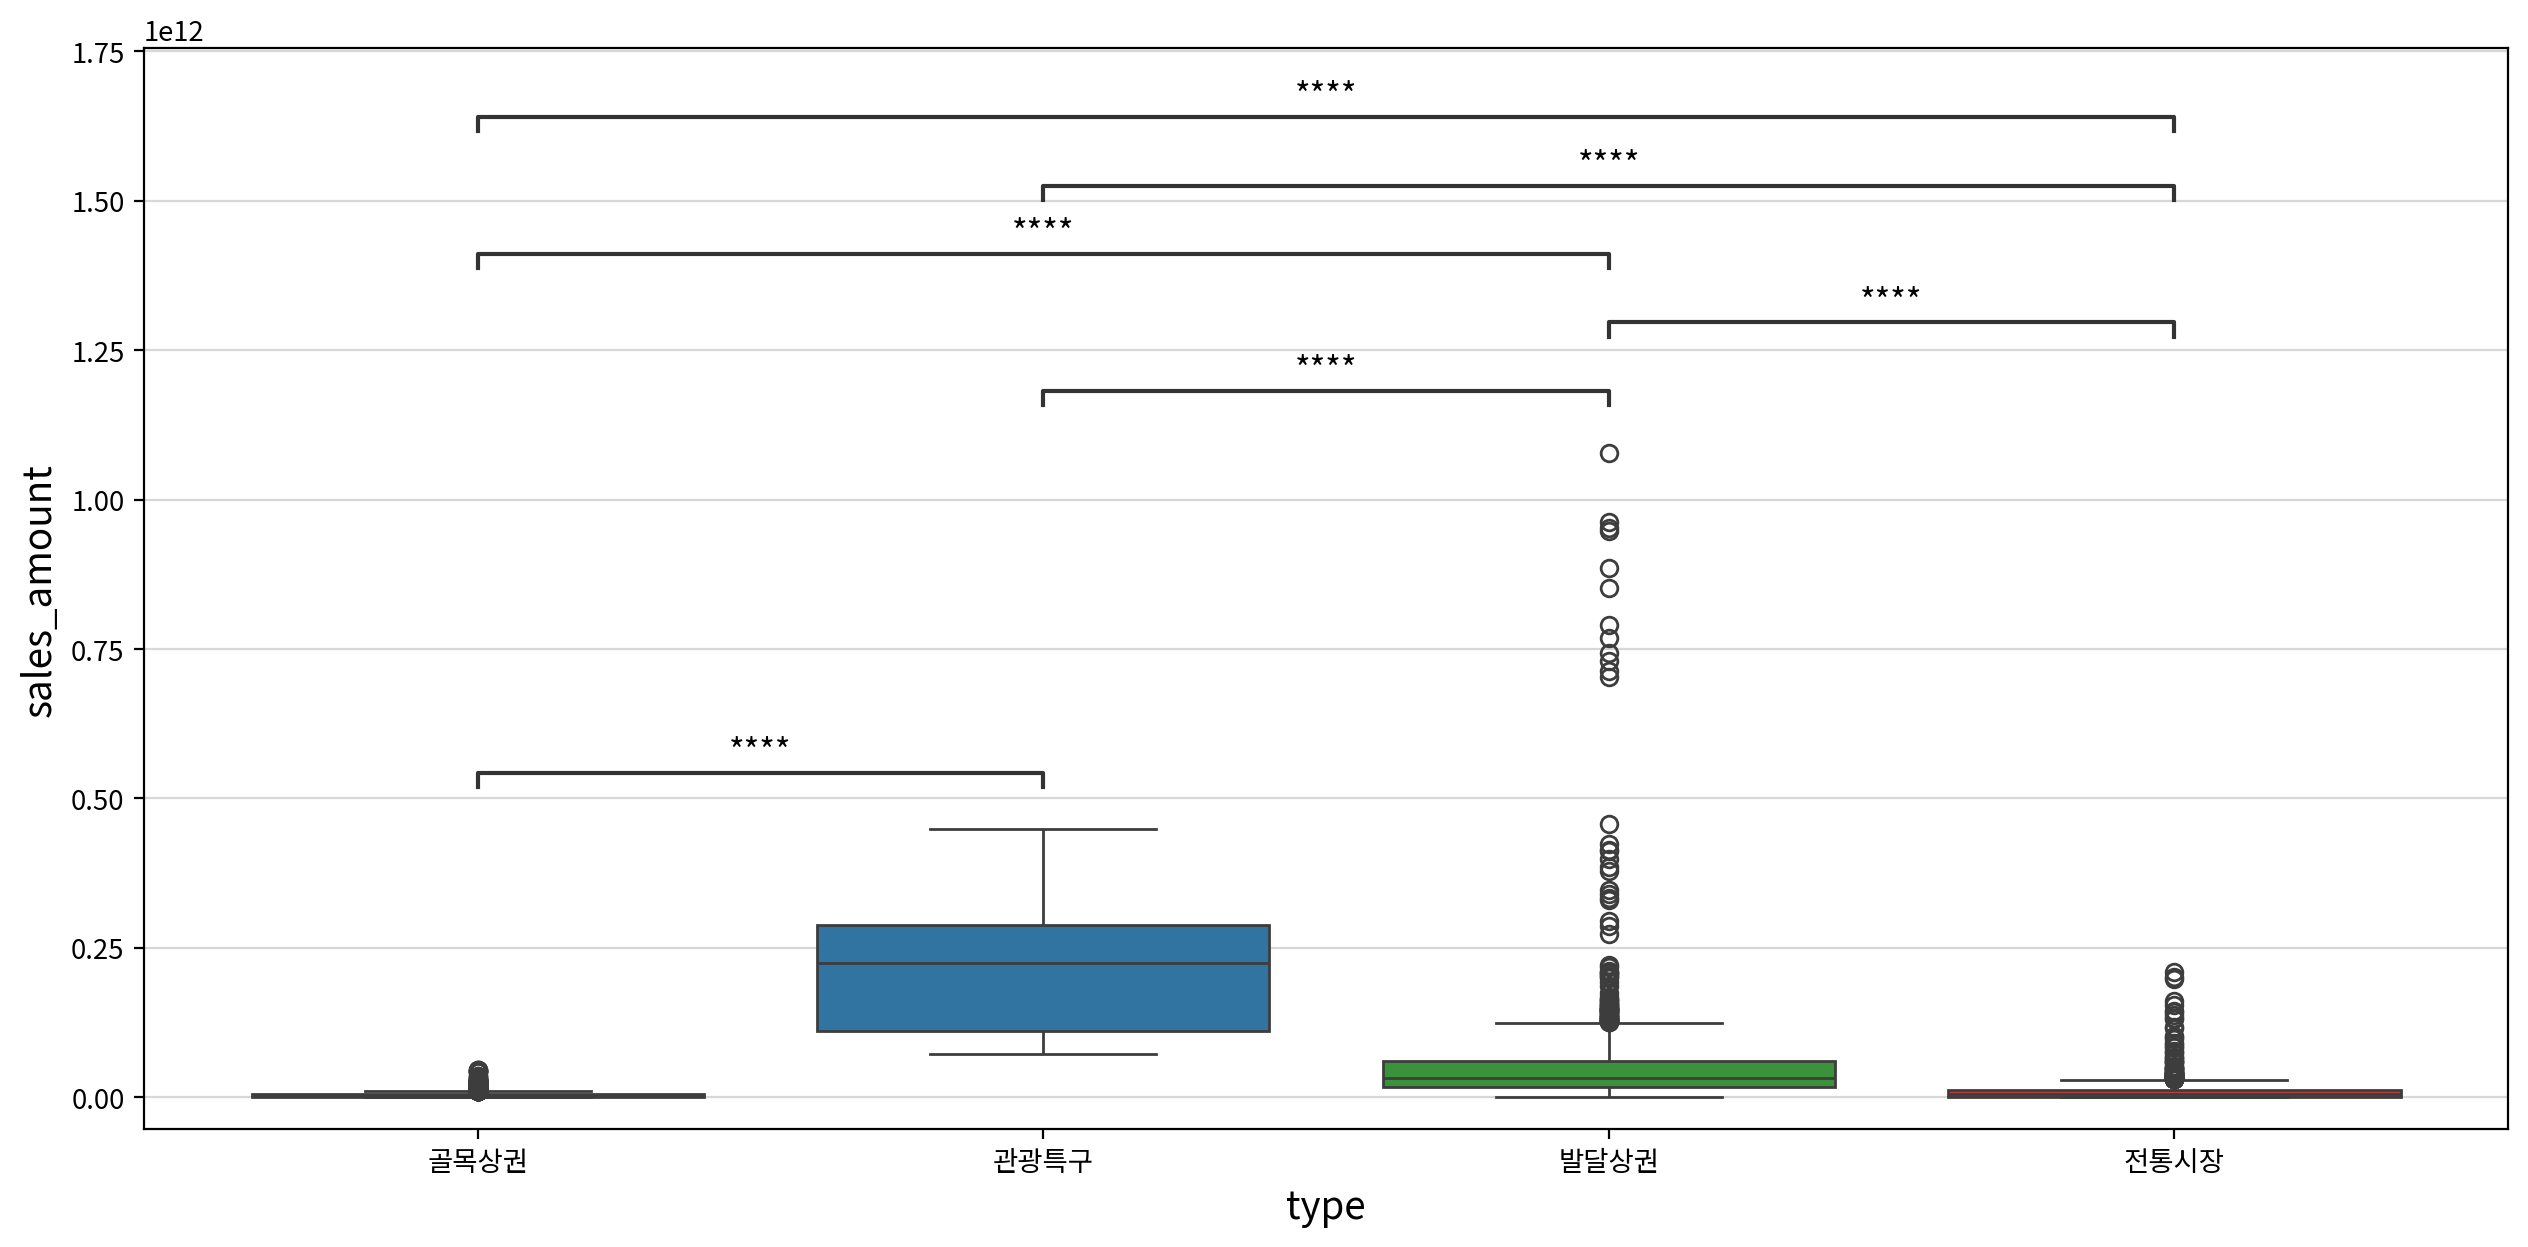

,test,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges,significant,effect_size
0,Games-Howell,골목상권,관광특구,3659508698.643,228143191041.625,-224483682342.982,22892159577.450,-9.806,23.001,0.000,-23.207,True,Large
1,Games-Howell,골목상권,발달상권,3659508698.643,57063096491.533,-53403587792.891,3282877885.264,-16.267,996.055,0.000,-1.160,True,Large
2,Games-Howell,골목상권,전통시장,3659508698.643,10584197874.740,-6924689176.098,606055894.461,-11.426,1143.188,0.000,-0.679,True,Medium
3,Games-Howell,관광특구,발달상권,228143191041.625,57063096491.533,171080094550.092,23126107295.058,7.398,23.955,0.000,1.647,True,Large
4,Games-Howell,관광특구,전통시장,228143191041.625,10584197874.740,217558993166.885,22899931335.272,9.500,23.032,0.000,8.537,True,Large
5,Games-Howell,발달상권,전통시장,57063096491.533,10584197874.740,46478898616.793,3336640863.245,13.930,1061.850,0.000,0.639,True,Medium


In [5]:
my_stats.posthoc_oneway(df2, y='sales_amount', between='type')

- 데이터가 등분산성을 만족하지 않아 Games-Howell을 수행하였다.
- 사후 분석 결과, 모든 집단의 평균 차이가 통계적으로 유의하였다(p <0.05)
- 골목상권과 관광특구의 평균은 각각 3659508698.643, 228143191041.625로 평균 차이는 -224483682342.982였으며 효과크기는 -23.207로 매우 큰 수준이었다. 즉 관광특구의 평균이 골목상권보다 유의하게 높았다.
- 골목상권과 발달상권의 평균은 각각 3659508698.643, 57063096491.533로 평균 차이는 -53403587792.891였으며 효과크기는 -1.160로 큰 수준이었다. 즉 발달상권의 평균이 골목상권보다 유의하게 높았다.
- 골목상권과 전통시장의 평균은 각각 3659508698.643, 10584197874.740로 평균 차이는 -6924689176.098였으며 효과크기는 -0.679로 중간 수준이었다. 즉 전통시장의 평균이 골목상권보다 유의하게 높았다.
- 관광특구와 발달상권의 평균은 각각 228143191041.625, 57063096491.533로 평균 차이는 171080094550.092였으며 효과크기는 1.647로 큰 수준이었다. 즉 관광특구의 평균이 발달상권보다 유의하게 높았다.
- 관광특구와 전통시장의 평균은 각각 228143191041.625, 10584197874.740로 평균 차이는 217558993166.885였으며 효과크기는 8.537로 큰 수준이었다. 즉 관광특구의 평균이 전통시장보다 유의하게 높았다.
- 발달상권과 전통시장의 평균은 각각 57063096491.533, 10584197874.740로 평균 차이는 46478898616.793였으며 효과크기는 0.639로 중간 수준이었다. 즉 발달상권의 평균이 전통시장보다 유의하게 높았다.

#### 문제 3 - 카페에서 음료 종류에 따라 매출 구분에 차이가 있는지 확인하라

In [6]:
df3 = load_data('cafe_sales')
df3.head()

📚 서울의 한 오피스 상권 카페에서 점심시간(11:30~13:30) 동안 판매된 음료 주문 데이터


,주문번호,주문시각,구분,메뉴명,사이즈,금액
0,1001,2026-03-31 11:32,커피,아메리카노,레귤러,4500
1,1002,2026-03-31 11:34,커피,카페라떼,레귤러,5000
2,1003,2026-03-31 11:35,커피,아메리카노,라지,5000
3,1004,2026-03-31 11:36,커피,콜드브루,레귤러,5300
4,1005,2026-03-31 11:38,에이드,자몽에이드,레귤러,5800


In [7]:
my_stats.anova_oneway(df3, y='금액', between='구분')

,test,Source,ddof1,ddof2,F,p_unc,np2,effect_size
0,welch_anova,구분,2,10.566,32.978,0.000,0.489,Large


- 검정 선택 : test=welch_anova → 등분산성을 위반하여 Welch ANOVA 검정으로 진행하였다.
- 유의성 : F(2, 10.566)=32.978, p=0.000<0.05 → 귀무가설 기각, 세가지 음료 종류 중 적어도 한종류의 매출 평균은 다르다.
- 효과 크기 : np2=0.489 → Large, 음료 종류의 매출 차이 변동의 약 48.9%를 설명, 통계적 유의성을 넘어 실질적으로도 큰 효과를 보였다.
- 다음 단계 : ANOVA는 '어딘가 차이가 있다'까지만 말해주므로, 어느 음료 종류의 쌍이 매출 금액이 다른지는 사후검정 등으로 확인 필요하다.

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

에이드 vs. 차: Custom statistical test, P_val:1.177e-04
차 vs. 커피: Custom statistical test, P_val:8.083e-01
에이드 vs. 커피: Custom statistical test, P_val:2.758e-05


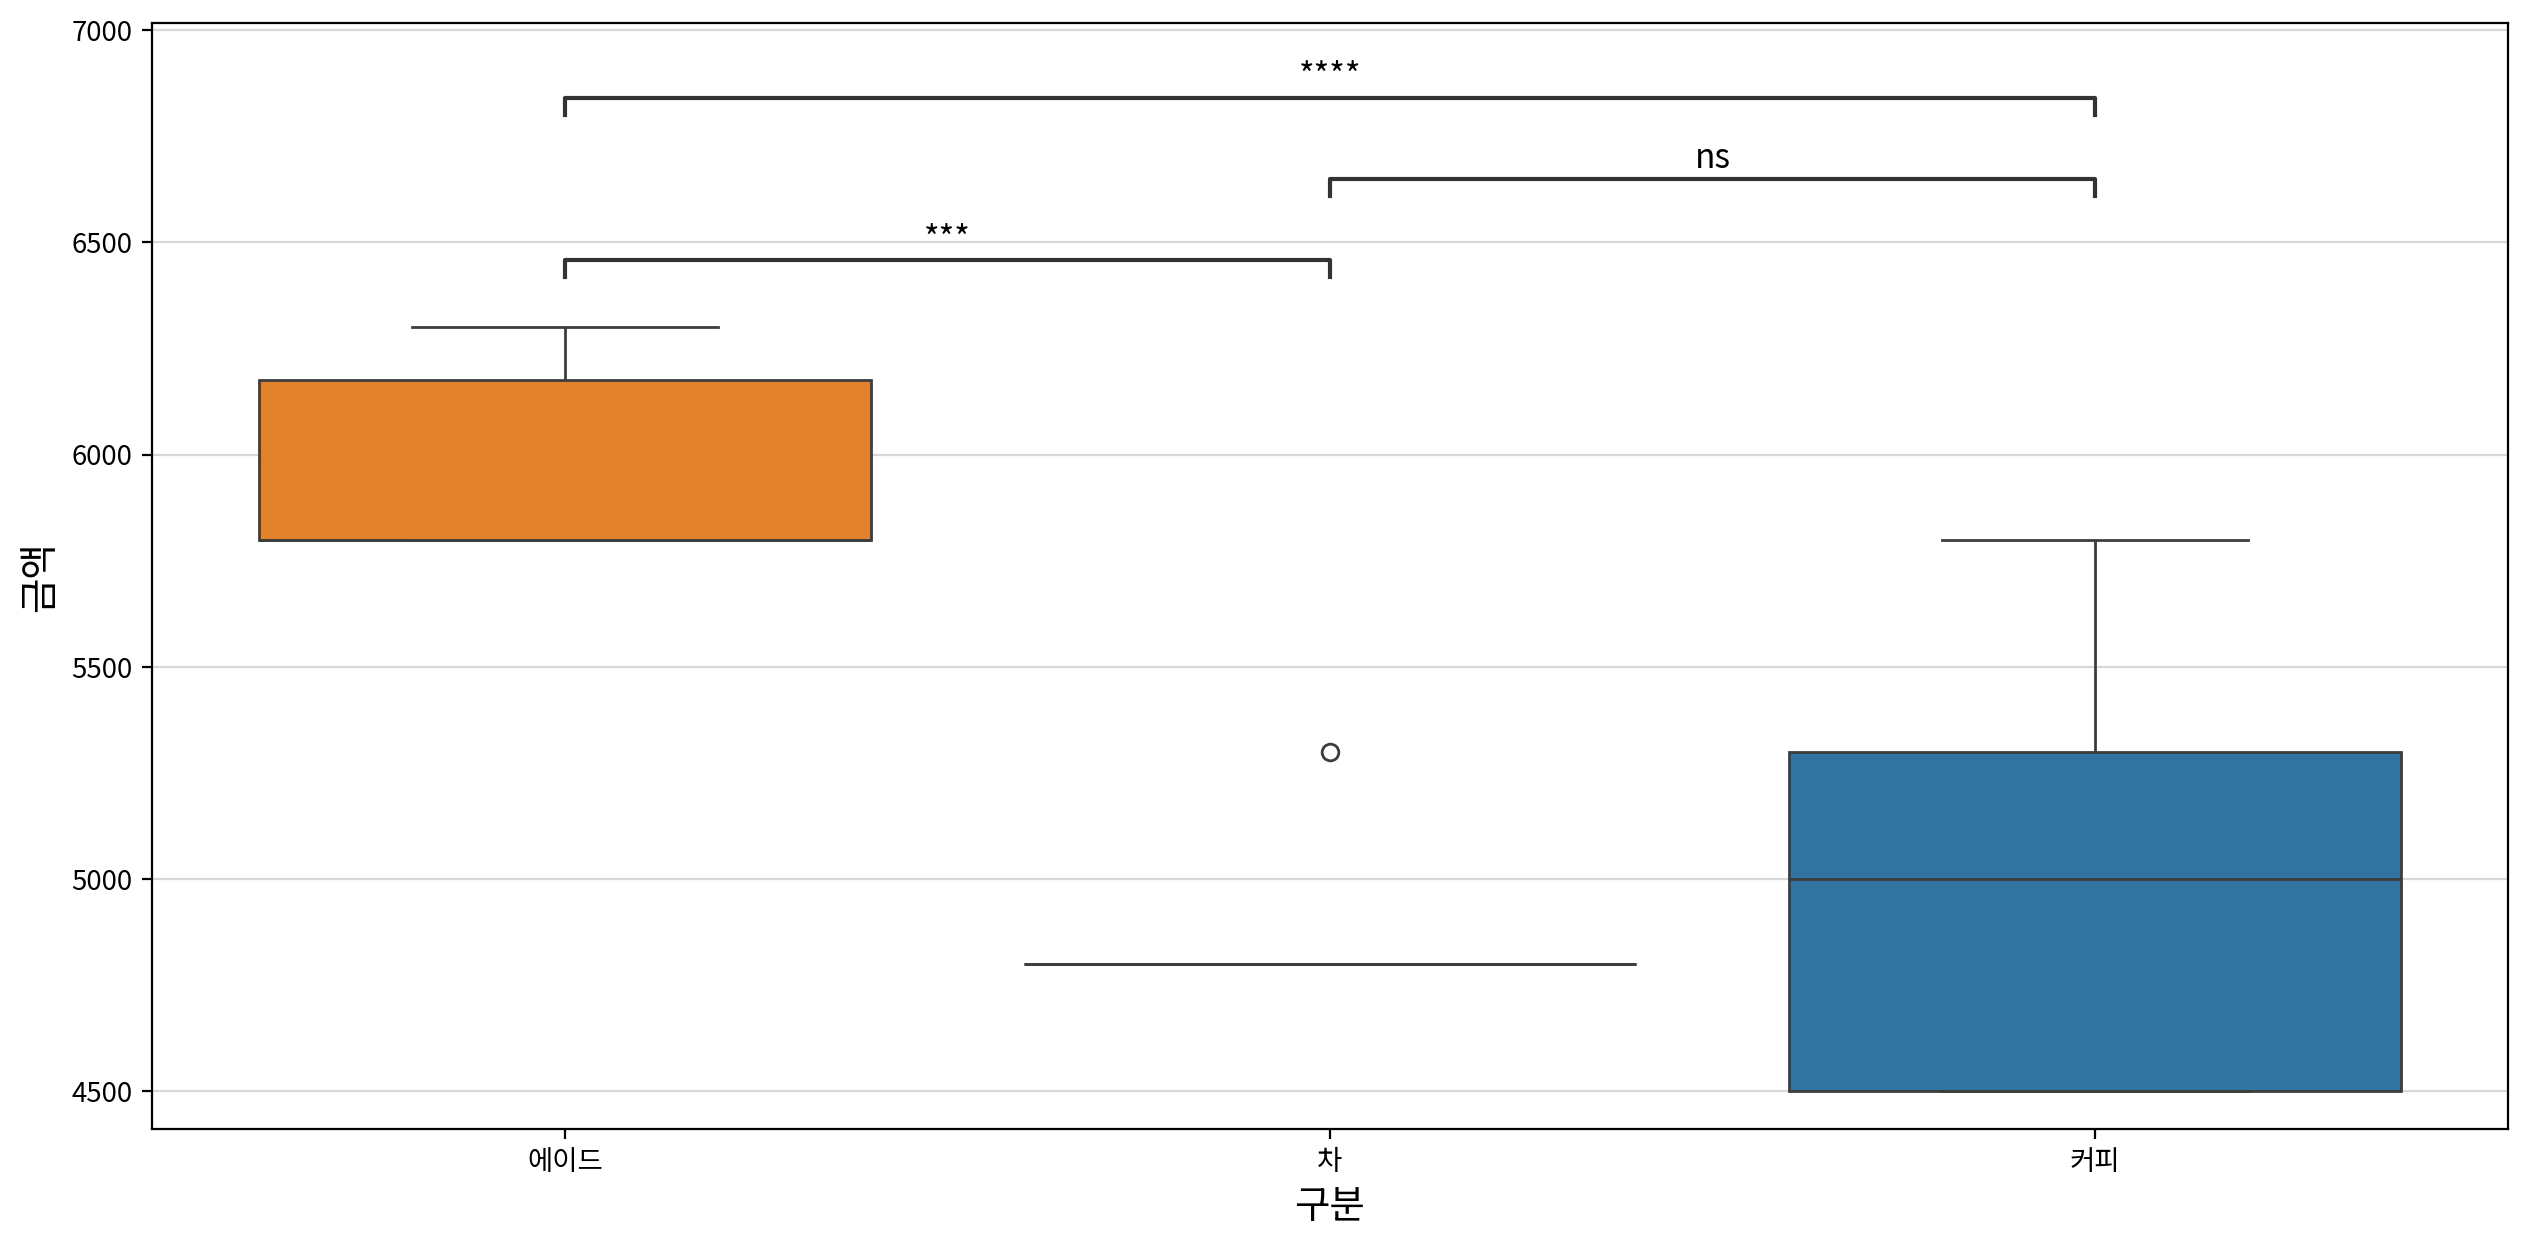

,test,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges,significant,effect_size
0,Games-Howell,에이드,차,5966.667,4900.000,1066.667,145.297,7.341,8.969,0.000,4.006,True,Large
1,Games-Howell,에이드,커피,5966.667,4979.310,987.356,130.506,7.566,11.181,0.000,2.444,True,Large
2,Games-Howell,차,커피,4900.000,4979.310,-79.310,126.177,-0.629,9.655,0.808,-0.196,False,Negligible


In [8]:
my_stats.posthoc_oneway(df3, y='금액', between='구분')

- 데이터가 등분산성을 만족하지 않아 Games-Howell을 수행하였다.
- 사후 분석 결과, 에이드와 차, 에이드와 커피의 평균 차이가 통계적으로 유의하였다(p <0.05)
- 에이드와 차의 평균은 각각 5966.667, 4900로 평균 차이는 1066.667였으며 효과크기는 4.006로 큰 수준이었다. 즉 에이드의 매출평균이 차보다 유의하게 높았다.
- 에이드와 커피의 평균은 각각 5966.667, 4979.31로 평균 차이는 987.356이었으며, 효과 크기는 2.444로 큰 수준이었다. 즉 에이드의 매출평균이 커피보다 유의하게 높았다.
- 반면 차와 커피(p>=0.05)의 매출 평균차이는 통계적으로 유의하지 않았다.

#### 문제 4- 요일별로 평균 팁 금액에 차이가 있는지 알아봐라

In [9]:
df4 = load_data('tips')
df4.head()

📚 식당 고객의 결제 금액, 팁, 성별, 흡연 여부, 요일, 시간대, 일행 규모 등 기본 정보를 담은 데이터 분석·시각화 실습용 샘플 데이터 (출처: https://www.kaggle.com/datasets/sakshisatre/tips-dataset)

field       description
----------  -------------
total_bill  총 결제 금액
tip         팁 금액
sex         성별
smoker      흡연 여부
day         방문 요일
time        방문 시간대
size        일행 규모



,total_bill,tip,sex,smoker,day,time,size
0,16.990,1.010,Female,No,Sun,Dinner,2
1,10.340,1.660,Male,No,Sun,Dinner,3
2,21.010,3.500,Male,No,Sun,Dinner,3
3,23.680,3.310,Male,No,Sun,Dinner,2
4,24.590,3.610,Female,No,Sun,Dinner,4


In [10]:
df4['day'].unique()

<ArrowStringArray>
['Sun', 'Sat', 'Thur', 'Fri']
Length: 4, dtype: str

In [11]:
my_stats.anova_oneway(df4, y='total_bill', between='day')

,test,Source,ddof1,ddof2,F,p_unc,np2,effect_size
0,welch_anova,day,3,75.305,3.011,0.035,0.033,Small


- 검정 선택 : test=welch_anova → 등분산성을 위반하여 Welch ANOVA 검정으로 진행하였다.
- 유의성 : F(3, 75.305)=3.011, p=0.035< 0.05 → 귀무가설을 기각하고 대립가설을 채택, 요일별로 주문금액에 차이가 있다.
- 효과 크기 : np2=0.020 → Small, 요일별로 평균 주문 금액의 차이가 약 3.3%를 설명, 통계적 유의성이 작다.(실질적으로 작은 효과)
- 다음 단계 : 요일별로 평균 주문금액에 차이가 있으므로 사후 검정 필요

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Fri vs. Sat: Custom statistical test, P_val:4.367e-01
Sat vs. Sun: Custom statistical test, P_val:9.064e-01
Sun vs. Thur: Custom statistical test, P_val:4.812e-02
Fri vs. Sun: Custom statistical test, P_val:2.210e-01
Sat vs. Thur: Custom statistical test, P_val:2.188e-01
Fri vs. Thur: Custom statistical test, P_val:9.946e-01


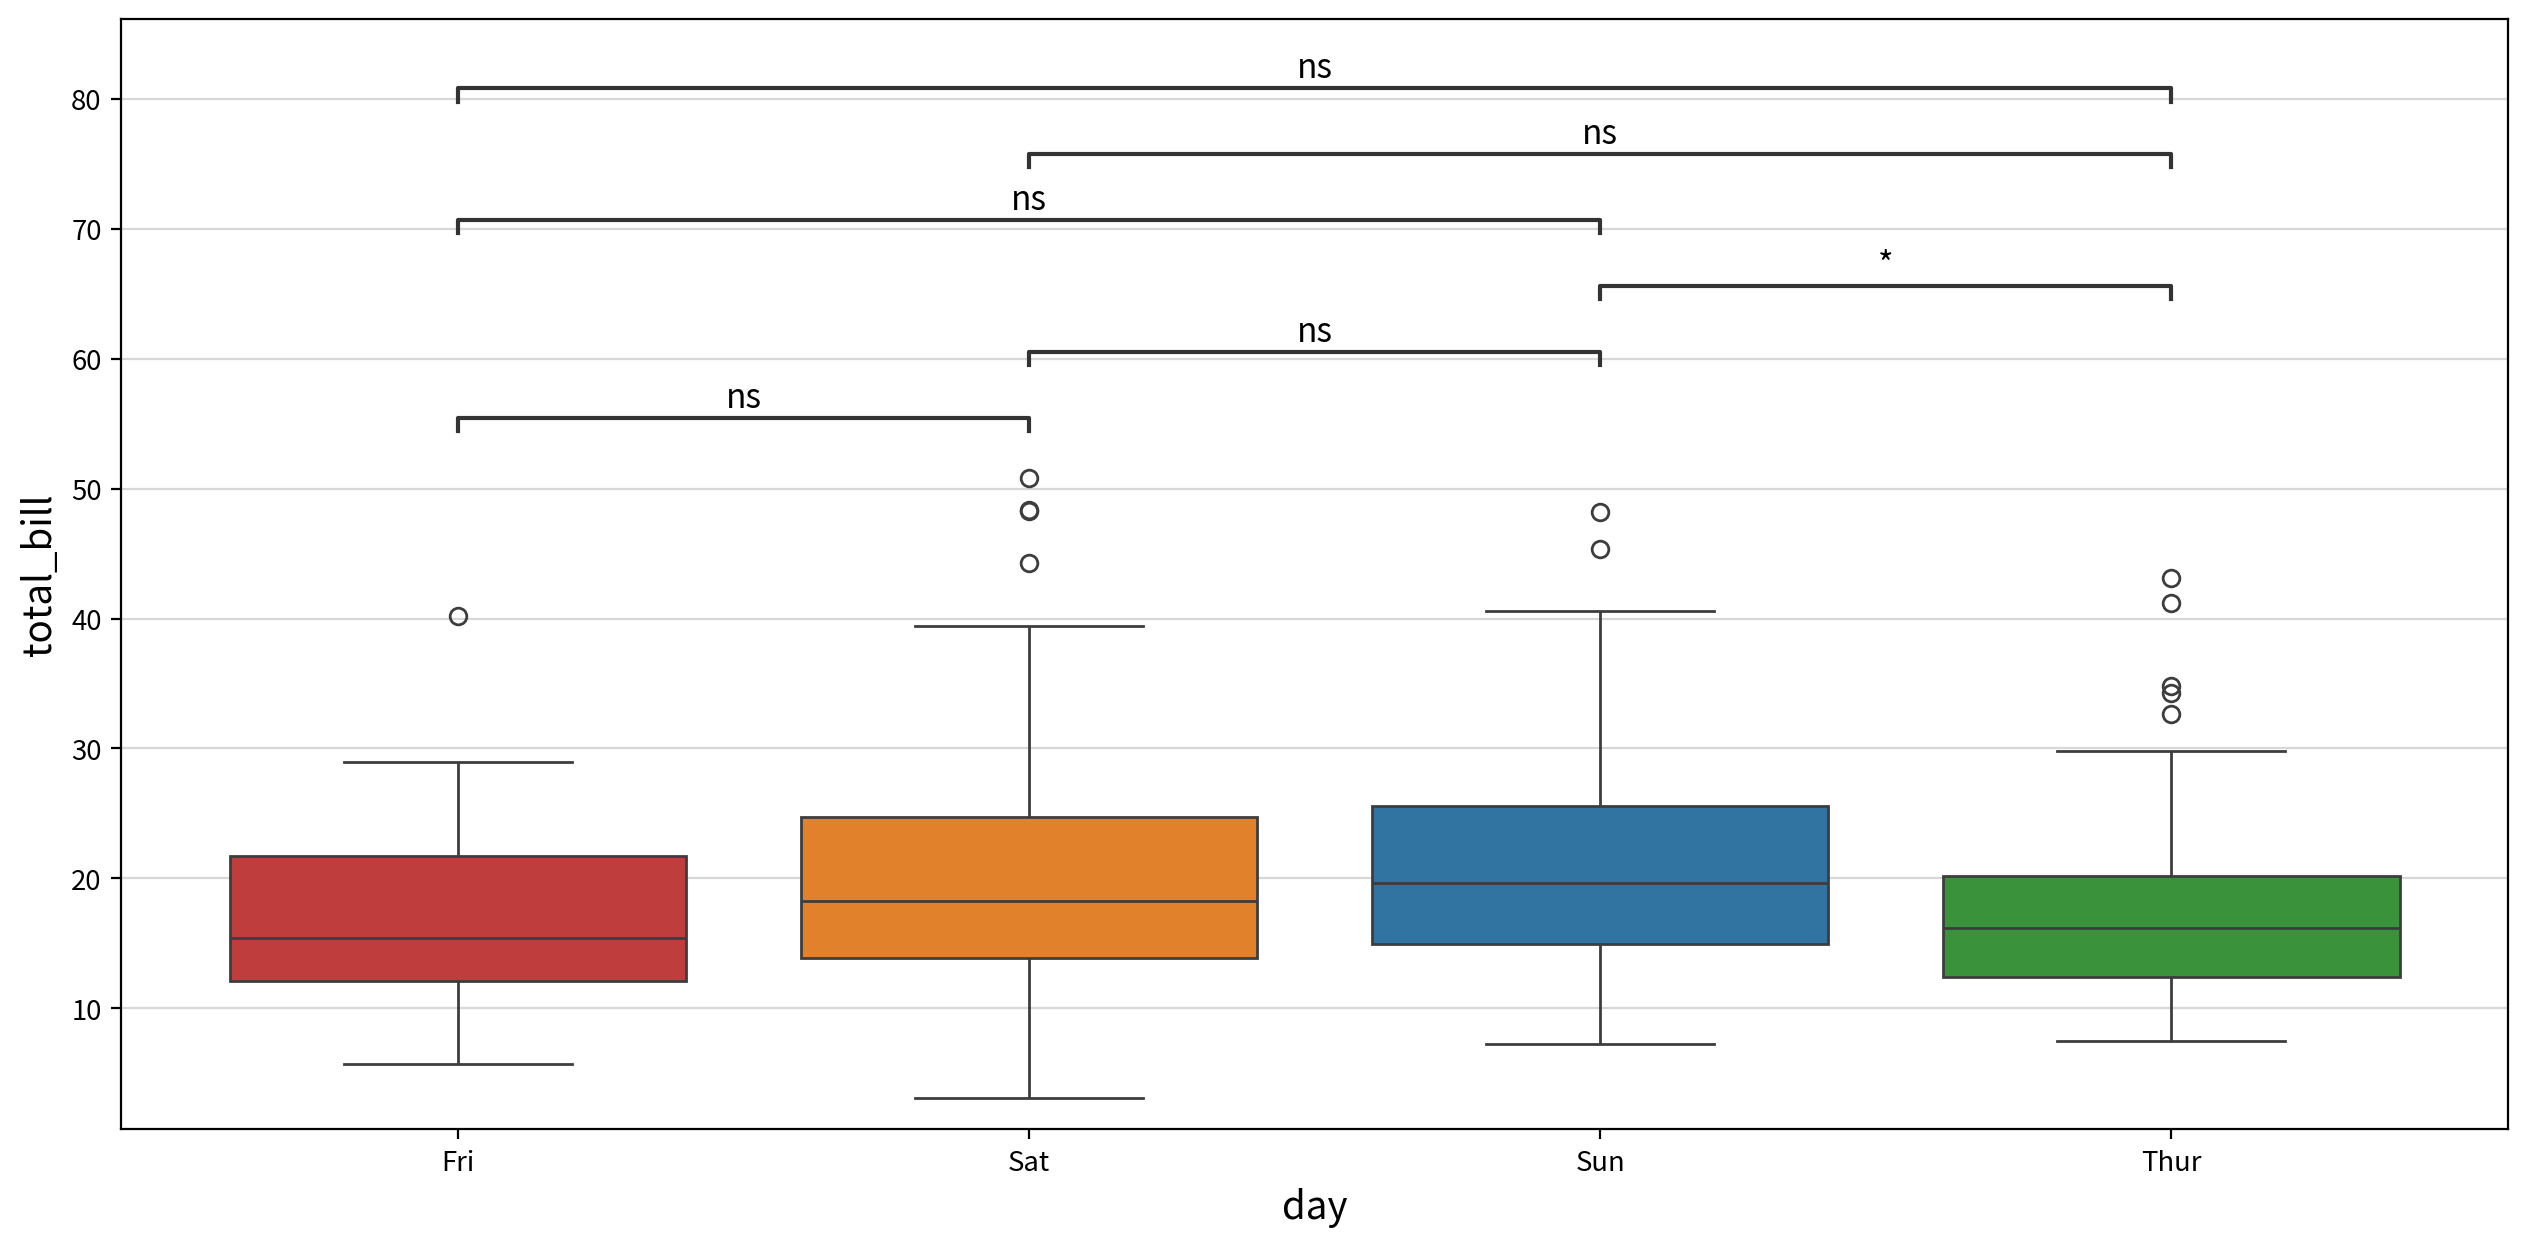

,test,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges,significant,effect_size
0,Games-Howell,Fri,Sat,17.152,20.441,-3.290,2.159,-1.524,29.214,0.437,-0.352,False,Small
1,Games-Howell,Fri,Sun,17.152,21.410,-4.258,2.157,-1.974,29.067,0.221,-0.484,False,Small
2,Games-Howell,Fri,Thur,17.152,17.683,-0.531,2.152,-0.247,28.682,0.995,-0.066,False,Negligible
3,Games-Howell,Sat,Sun,20.441,21.410,-0.969,1.435,-0.675,160.318,0.906,-0.105,False,Negligible
4,Games-Howell,Sat,Thur,20.441,17.683,2.759,1.427,1.933,143.436,0.219,0.310,False,Small
5,Games-Howell,Sun,Thur,21.410,17.683,3.727,1.425,2.616,134.860,0.048,0.440,True,Small


In [12]:
my_stats.posthoc_oneway(df4, y='total_bill', between='day')

- 데이터가 등분산성을 만족하지 않아 Games-Howell을 수행하였다.
- 사후 분석 결과, 일요일과 목요일의 주문금액평균 차이가 통계적으로 유의하였다(p <0.05)
- 일요일과 목요일의 평균은 각각 21.41, 17.683로 평균 차이는 3.727이었으며, 효과 크기는 0.440로 작은 수준이었다. 즉 일요일의 주문금액이 목요일보다 유의하게 높았다.
- 반면 금요일과 토요일, 금요일과 일요일, 금요일과 목요일, 토요일과 일요일, 토요일과 목요일(p>=0.05)의 주문 금액 평균차이는 통계적으로 유의하지 않았다.